Importing Libraries

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from scipy.stats import pearsonr

Data Collection

In [2]:
df=pd.read_csv("Gaming and Mental Health.csv")
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low


In [3]:
df.dtypes

record_id                            object
age                                   int64
gender                               object
daily_gaming_hours                  float64
game_genre                           object
primary_game                         object
gaming_platform                      object
sleep_hours                         float64
sleep_quality                        object
sleep_disruption_frequency           object
academic_work_performance            object
grades_gpa                          float64
work_productivity_score             float64
mood_state                           object
mood_swing_frequency                 object
withdrawal_symptoms                    bool
loss_of_other_interests                bool
continued_despite_problems             bool
eye_strain                             bool
back_neck_pain                         bool
weight_change_kg                    float64
exercise_hours_weekly               float64
social_isolation_score          

Data Preprocessing

In [4]:
#Handling missing Values
df.isnull().sum()


record_id                             0
age                                   0
gender                                0
daily_gaming_hours                    0
game_genre                            0
primary_game                          0
gaming_platform                       0
sleep_hours                           0
sleep_quality                         0
sleep_disruption_frequency            0
academic_work_performance             0
grades_gpa                          246
work_productivity_score             326
mood_state                            0
mood_swing_frequency                  0
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                      0
exercise_hours_weekly                 0
social_isolation_score                0
face_to_face_social_hours_weekly      0
monthly_game_spending_usd             0


In [5]:
df['grades_gpa']=df['grades_gpa'].fillna(df['grades_gpa'].median())
df['work_productivity_score']=df['work_productivity_score'].fillna(df['work_productivity_score'].median())

In [6]:
df.isnull().sum()

record_id                           0
age                                 0
gender                              0
daily_gaming_hours                  0
game_genre                          0
primary_game                        0
gaming_platform                     0
sleep_hours                         0
sleep_quality                       0
sleep_disruption_frequency          0
academic_work_performance           0
grades_gpa                          0
work_productivity_score             0
mood_state                          0
mood_swing_frequency                0
withdrawal_symptoms                 0
loss_of_other_interests             0
continued_despite_problems          0
eye_strain                          0
back_neck_pain                      0
weight_change_kg                    0
exercise_hours_weekly               0
social_isolation_score              0
face_to_face_social_hours_weekly    0
monthly_game_spending_usd           0
years_gaming                        0
gaming_addic

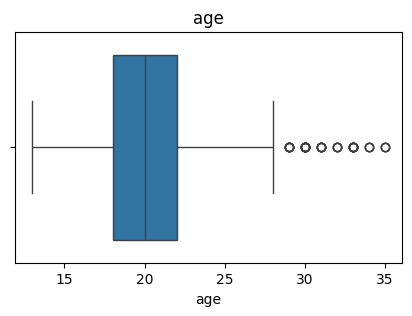

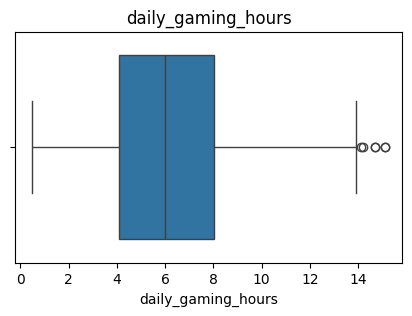

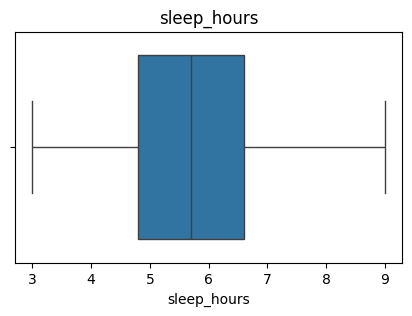

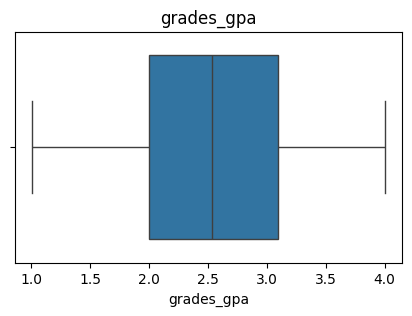

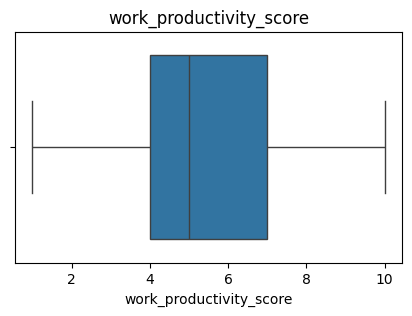

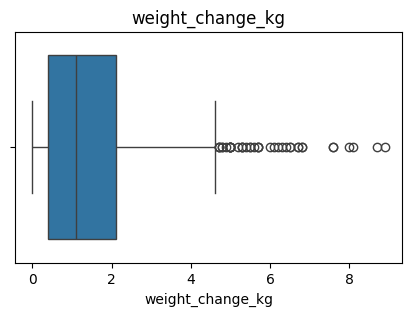

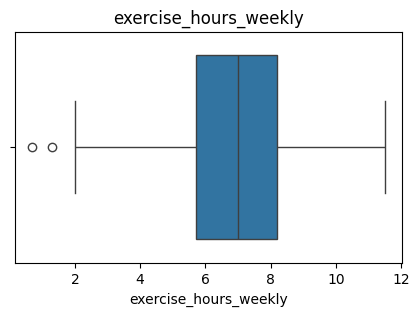

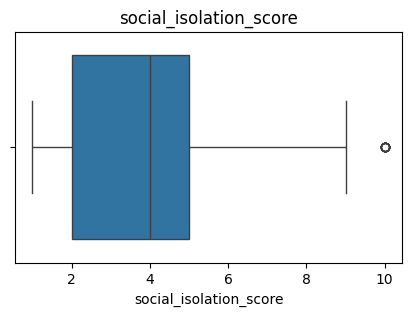

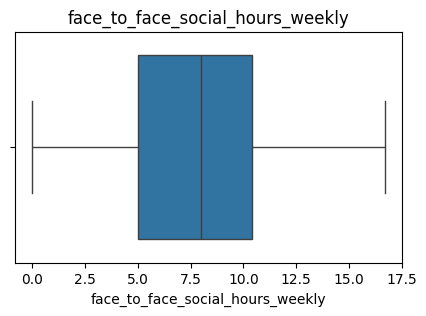

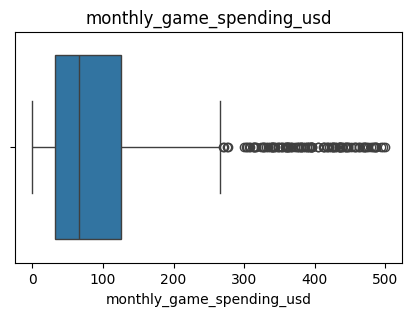

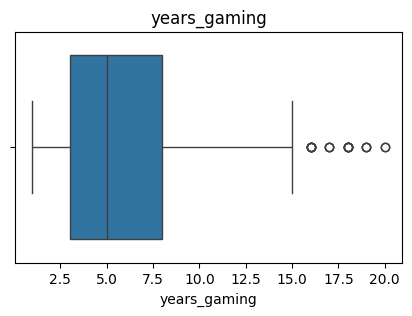

In [7]:
#Outliers Detection
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [8]:
for col in num_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lower=q1-(1.5*IQR)
    upper=q3+(1.5*IQR)
    outliers=df[(df[col]<lower) | (df[col]>upper)]
    print(f"{col}: {outliers.shape[0]} outliers")


age: 50 outliers
daily_gaming_hours: 6 outliers
sleep_hours: 0 outliers
grades_gpa: 0 outliers
work_productivity_score: 0 outliers
weight_change_kg: 40 outliers
exercise_hours_weekly: 2 outliers
social_isolation_score: 10 outliers
face_to_face_social_hours_weekly: 0 outliers
monthly_game_spending_usd: 107 outliers
years_gaming: 20 outliers


Outlier analysis using boxplots indicated the presence of extreme values in gaming hours, sleep, social interaction, and monthly spending. 
These values were retained as they represent genuine behavioral patterns related to addiction severity rather than data errors, 
and removing them could reduce the model’s predictive capability.

In [9]:
#changing Features data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        1000 non-null   float64
 12  work_pr

In [10]:
df=pd.get_dummies(df,columns=['gender','game_genre','primary_game','gaming_platform','mood_state'],drop_first=True)
df

,record_id,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_swing_frequency,...,gaming_platform_Multi-platform,gaming_platform_PC,mood_state_Anxious,mood_state_Depressed,mood_state_Euphoric,mood_state_Excited,mood_state_Irritable,mood_state_Normal,mood_state_Restless,mood_state_Withdrawn
0,GD0001,17,11.1,3.7,Very Poor,Sometimes,Below Average,1.25,5.0,Never,...,False,True,True,False,False,False,False,False,False,False
1,GD0002,21,3.0,7.2,Fair,Rarely,Good,3.75,2.0,Often,...,False,True,False,False,False,False,True,False,False,False
2,GD0003,23,7.6,4.4,Fair,Often,Poor,2.53,9.0,Rarely,...,True,False,False,False,False,False,True,False,False,False
3,GD0004,20,7.2,5.1,Fair,Often,Poor,1.62,2.0,Daily,...,True,False,False,False,False,False,False,False,False,True
4,GD0005,18,6.8,3.4,Poor,Never,Average,2.44,5.0,Daily,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,8.6,4.1,Very Poor,Always,Average,2.96,5.0,Sometimes,...,False,True,False,False,False,False,False,False,True,False
996,GD0997,18,5.4,6.5,Fair,Never,Excellent,3.42,5.0,Often,...,True,False,False,False,False,False,False,False,False,False
997,GD0998,23,7.3,3.9,Insomnia,Rarely,Poor,2.53,3.0,Daily,...,False,True,False,False,False,False,False,False,False,True
998,GD0999,18,3.1,8.2,Fair,Sometimes,Good,1.03,5.0,Rarely,...,False,False,False,False,False,False,False,True,False,False


In [11]:
bools=df.select_dtypes(include='bool').columns
df[bools]=df[bools].astype(int)
df

,record_id,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_swing_frequency,...,gaming_platform_Multi-platform,gaming_platform_PC,mood_state_Anxious,mood_state_Depressed,mood_state_Euphoric,mood_state_Excited,mood_state_Irritable,mood_state_Normal,mood_state_Restless,mood_state_Withdrawn
0,GD0001,17,11.1,3.7,Very Poor,Sometimes,Below Average,1.25,5.0,Never,...,0,1,1,0,0,0,0,0,0,0
1,GD0002,21,3.0,7.2,Fair,Rarely,Good,3.75,2.0,Often,...,0,1,0,0,0,0,1,0,0,0
2,GD0003,23,7.6,4.4,Fair,Often,Poor,2.53,9.0,Rarely,...,1,0,0,0,0,0,1,0,0,0
3,GD0004,20,7.2,5.1,Fair,Often,Poor,1.62,2.0,Daily,...,1,0,0,0,0,0,0,0,0,1
4,GD0005,18,6.8,3.4,Poor,Never,Average,2.44,5.0,Daily,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,8.6,4.1,Very Poor,Always,Average,2.96,5.0,Sometimes,...,0,1,0,0,0,0,0,0,1,0
996,GD0997,18,5.4,6.5,Fair,Never,Excellent,3.42,5.0,Often,...,1,0,0,0,0,0,0,0,0,0
997,GD0998,23,7.3,3.9,Insomnia,Rarely,Poor,2.53,3.0,Daily,...,0,1,0,0,0,0,0,0,0,1
998,GD0999,18,3.1,8.2,Fair,Sometimes,Good,1.03,5.0,Rarely,...,0,0,0,0,0,0,0,1,0,0


In [12]:
df['sleep_quality'].unique()

array(['Very Poor', 'Fair', 'Poor', 'Insomnia', 'Good'], dtype=object)

In [13]:
df['sleep_quality'] = df['sleep_quality'].map({
    'Very Poor': 0,
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Insomnia': 4
})
df['sleep_quality']

0      0
1      2
2      2
3      2
4      1
      ..
995    0
996    2
997    4
998    2
999    3
Name: sleep_quality, Length: 1000, dtype: int64

In [14]:
df['sleep_disruption_frequency'].unique()

array(['Sometimes', 'Rarely', 'Often', 'Never', 'Always'], dtype=object)

In [15]:
df['sleep_disruption_frequency'] = df['sleep_disruption_frequency'].map({
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Always': 4
})
df['sleep_disruption_frequency']

0      2
1      1
2      3
3      3
4      0
      ..
995    4
996    0
997    1
998    2
999    2
Name: sleep_disruption_frequency, Length: 1000, dtype: int64

In [16]:
df['academic_work_performance'].unique()

array(['Below Average', 'Good', 'Poor', 'Average', 'Excellent', 'Failing'],
      dtype=object)

In [17]:
df['academic_work_performance'] = df['academic_work_performance'].map({
    'Failing': 0,
    'Poor': 1,
    'Below Average': 2,
    'Average': 3,
    'Good': 4,
    'Excellent': 5
})
df['academic_work_performance']

0      2
1      4
2      1
3      1
4      3
      ..
995    3
996    5
997    1
998    4
999    2
Name: academic_work_performance, Length: 1000, dtype: int64

In [18]:
df['mood_swing_frequency'].unique()

array(['Never', 'Often', 'Rarely', 'Daily', 'Sometimes'], dtype=object)

In [19]:
df['mood_swing_frequency'] = df['mood_swing_frequency'].map({
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Daily': 4
})
df['mood_swing_frequency']

0      0
1      3
2      1
3      4
4      4
      ..
995    2
996    3
997    4
998    1
999    4
Name: mood_swing_frequency, Length: 1000, dtype: int64

In [20]:
df.columns

Index(['record_id', 'age', 'daily_gaming_hours', 'sleep_hours',
       'sleep_quality', 'sleep_disruption_frequency',
       'academic_work_performance', 'grades_gpa', 'work_productivity_score',
       'mood_swing_frequency', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly',
       'social_isolation_score', 'face_to_face_social_hours_weekly',
       'monthly_game_spending_usd', 'years_gaming',
       'gaming_addiction_risk_level', 'gender_Male', 'gender_Other',
       'game_genre_FPS', 'game_genre_MMO', 'game_genre_MOBA',
       'game_genre_Mobile Games', 'game_genre_RPG', 'game_genre_Strategy',
       'primary_game_Apex Legends', 'primary_game_CS:GO',
       'primary_game_Call of Duty', 'primary_game_Candy Crush',
       'primary_game_Civilization VI', 'primary_game_Clash of Clans',
       'primary_game_Cyberpunk 2077', 'primary_game_Dota 2',
       'primary_game_El

In [21]:
df['gaming_addiction_risk_level'].unique()

array(['Severe', 'Low', 'High', 'Moderate'], dtype=object)

In [22]:
df['gaming_addiction_risk_level'] = df['gaming_addiction_risk_level'].map({
    'Low': 0,
    'Moderate': 1,
    'High': 2,
    'Severe': 3
})
df['gaming_addiction_risk_level']

0      3
1      0
2      3
3      2
4      1
      ..
995    3
996    0
997    2
998    0
999    0
Name: gaming_addiction_risk_level, Length: 1000, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 64 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   record_id                          1000 non-null   object 
 1   age                                1000 non-null   int64  
 2   daily_gaming_hours                 1000 non-null   float64
 3   sleep_hours                        1000 non-null   float64
 4   sleep_quality                      1000 non-null   int64  
 5   sleep_disruption_frequency         1000 non-null   int64  
 6   academic_work_performance          1000 non-null   int64  
 7   grades_gpa                         1000 non-null   float64
 8   work_productivity_score            1000 non-null   float64
 9   mood_swing_frequency               1000 non-null   int64  
 10  withdrawal_symptoms                1000 non-null   int64  
 11  loss_of_other_interests            1000 non-null   int64 

In [24]:
df=df.drop(columns=['record_id'])

In [25]:
df[df.duplicated()]

,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_swing_frequency,withdrawal_symptoms,...,gaming_platform_Multi-platform,gaming_platform_PC,mood_state_Anxious,mood_state_Depressed,mood_state_Euphoric,mood_state_Excited,mood_state_Irritable,mood_state_Normal,mood_state_Restless,mood_state_Withdrawn


Exploratory Data Analysis 

In [26]:
des=df.describe()
des

,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_swing_frequency,withdrawal_symptoms,...,gaming_platform_Multi-platform,gaming_platform_PC,mood_state_Anxious,mood_state_Depressed,mood_state_Euphoric,mood_state_Excited,mood_state_Irritable,mood_state_Normal,mood_state_Restless,mood_state_Withdrawn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,1.653000,1.990000,2.59400,2.52098,5.266000,2.018000,0.288000,...,0.260000,0.241000,0.169000,0.088000,0.107000,0.040000,0.147000,0.172000,0.135000,0.040000
std,4.116105,2.867194,1.441213,1.106262,1.392781,1.39754,0.75735,2.386407,1.405579,0.453058,...,0.438854,0.427904,0.374939,0.283437,0.309268,0.196057,0.354283,0.377569,0.341895,0.196057
min,13.000000,0.500000,3.000000,0.000000,0.000000,0.00000,1.01000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,4.100000,4.800000,1.000000,1.000000,2.00000,1.99750,4.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,20.000000,6.000000,5.700000,2.000000,2.000000,3.00000,2.53000,5.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,22.000000,8.025000,6.600000,2.000000,3.000000,4.00000,3.09000,7.000000,3.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,35.000000,15.100000,9.000000,4.000000,4.000000,5.00000,4.00000,10.000000,4.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Univeriate Analysis

Target Variable – Gaming Addiction Risk Level

In [27]:
#What is the class distribution? Is it imbalanced?
df['gaming_addiction_risk_level'].value_counts()

gaming_addiction_risk_level
0    514
1    190
2    154
3    142
Name: count, dtype: int64

In [28]:
#What percentage of students fall into each risk category?
df['gaming_addiction_risk_level'].value_counts(normalize=True)*100

gaming_addiction_risk_level
0    51.4
1    19.0
2    15.4
3    14.2
Name: proportion, dtype: float64

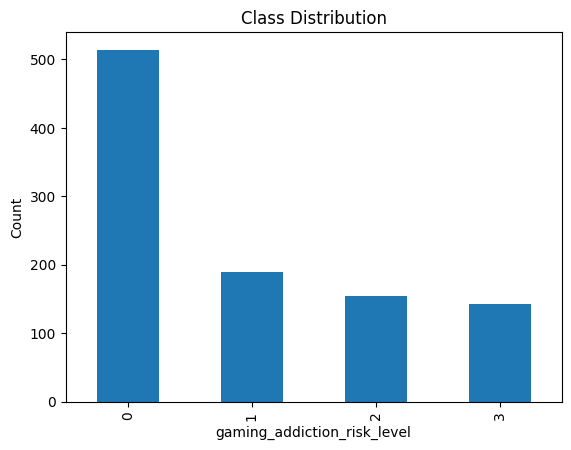

In [29]:
#Visulisation
df['gaming_addiction_risk_level'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

Daily Gaming Hours

In [30]:
#What is the average daily gaming time?
df['daily_gaming_hours'].mean()

np.float64(6.1514)

In [31]:
#What is the median of daily gaming time?
df['daily_gaming_hours'].median()

np.float64(6.0)

In [32]:
#Are there unrealistic values (e.g., 18+ hours per day)?
df['daily_gaming_hours'].max()

np.float64(15.1)

In [33]:
#What is the median vs mean? Is there heavy skew?
df['daily_gaming_hours'].skew()

np.float64(0.3508182924620857)

Mean ≈ Median
So distribution is roughly symmetric or only slightly right-skewed.

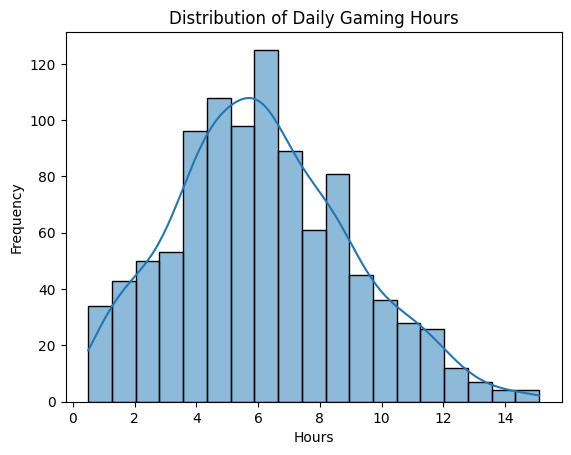

In [34]:
#Visualisation
sns.histplot(df['daily_gaming_hours'], kde=True)
plt.title("Distribution of Daily Gaming Hours")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

Sleep Hours


In [35]:
#What is the typical sleep duration?
print(df['sleep_hours'].mean())
print(df['sleep_hours'].median())

5.7381
5.7


In [36]:
#Are there extreme low values (3–4 hours)?
df['sleep_hours'].min()

np.float64(3.0)

In [37]:
#Is the distribution normal or skewed?
df['sleep_hours'].skew()

np.float64(0.22890424375388896)

The distribution is normal.

In [38]:
#What percentage of students sleeping<-4 hours
(df['sleep_hours']<=4).mean()*100

np.float64(14.7)

Grades (GPA)

count    1000.00000
mean        2.52098
std         0.75735
min         1.01000
25%         1.99750
50%         2.53000
75%         3.09000
max         4.00000
Name: grades_gpa, dtype: float64
Skew:  -0.06808867738528122


<Axes: xlabel='grades_gpa', ylabel='Count'>

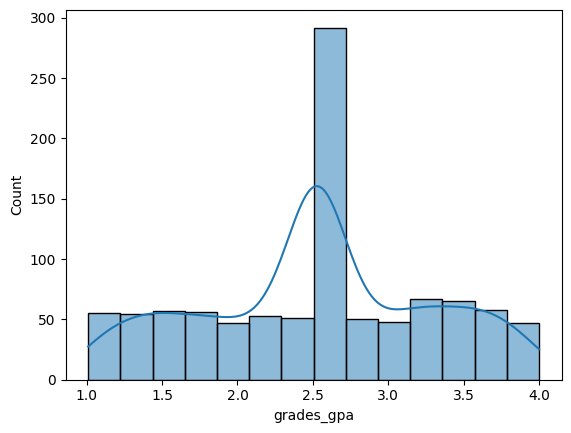

In [39]:
#Is GPA normally distributed?
print(df['grades_gpa'].describe())
print("Skew: ",df['grades_gpa'].skew())
sns.histplot(df['grades_gpa'], kde=True)

Monthly Game Spending

Skew:  1.842069199997397
count    1000.000000
mean      105.219730
std       113.886768
min         0.100000
25%        32.592500
50%        66.405000
75%       126.242500
max       499.270000
Name: monthly_game_spending_usd, dtype: float64


<Axes: xlabel='monthly_game_spending_usd', ylabel='Count'>

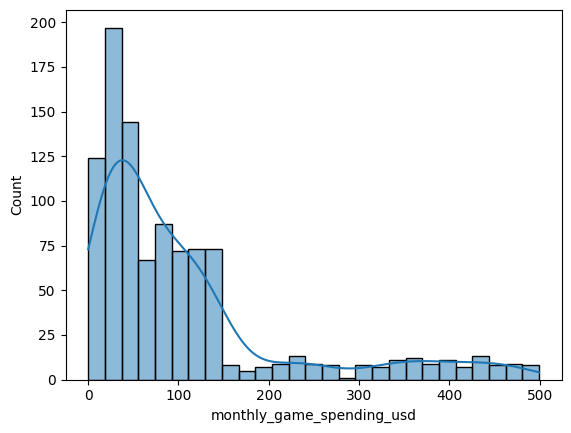

In [40]:
#Is spending highly skewed?
print("Skew: ",df['monthly_game_spending_usd'].skew())
print(df['monthly_game_spending_usd'].describe())
sns.histplot(df['monthly_game_spending_usd'], kde=True)

In [41]:
#How many zero spenders?
(df['monthly_game_spending_usd']==0).sum()

np.int64(0)

Exercise Hours Weekly

In [42]:
#How many report zero exercise?
(df['exercise_hours_weekly']==0).sum()

np.int64(0)

Skew= -0.1633966875203718
count    1000.000000
mean        6.945900
std         1.805027
min         0.700000
25%         5.700000
50%         7.000000
75%         8.200000
max        11.500000
Name: exercise_hours_weekly, dtype: float64


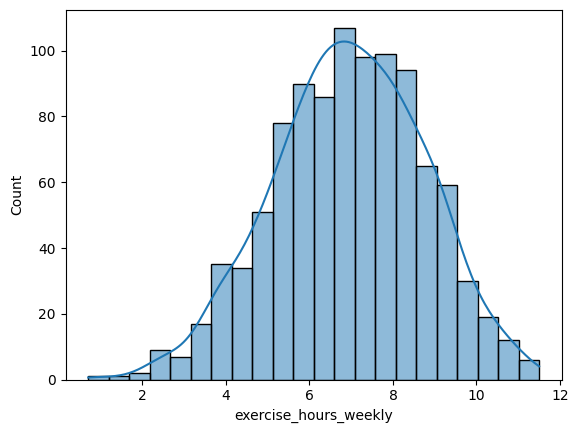

In [43]:
#Is exercise normally distributed?
print('Skew=',df['exercise_hours_weekly'].skew())
print(df['exercise_hours_weekly'].describe())
sns.histplot(df['exercise_hours_weekly'], kde=True)
plt.show()

Face-to-Face Social Hours

Skew:  -0.15797120960118177
count    1000.000000
mean        7.654500
std         3.751954
min         0.000000
25%         5.000000
50%         8.000000
75%        10.400000
max        16.700000
Name: face_to_face_social_hours_weekly, dtype: float64


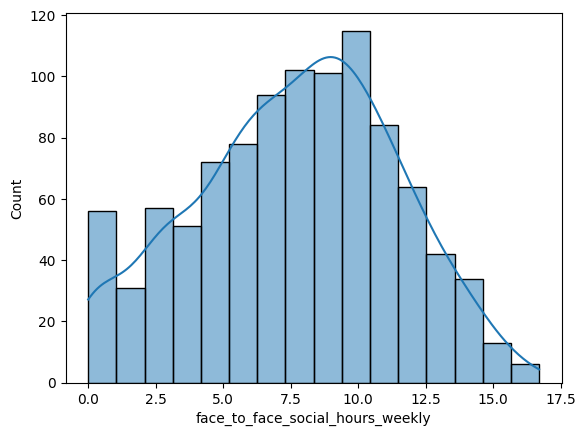

In [44]:
#What is the distribution?
print("Skew: ",df['face_to_face_social_hours_weekly'].skew())
print(df['face_to_face_social_hours_weekly'].describe())
sns.histplot(df['face_to_face_social_hours_weekly'], kde=True)
plt.show()

In [45]:
#Are there socially isolated individuals (near zero hours)?
(df['face_to_face_social_hours_weekly']==0).sum()

np.int64(30)

In [46]:
(df['face_to_face_social_hours_weekly']==0).mean()*100

np.float64(3.0)

Weight Change

In [47]:
#Is weight gain or loss more common?
gain = (df['weight_change_kg'] > 0).sum()
loss = (df['weight_change_kg'] < 0).sum()
no_change = (df['weight_change_kg'] == 0).sum()

print("Weight gain:", gain)
print("Weight loss:", loss)
print("No change:", no_change)

Weight gain: 973
Weight loss: 0
No change: 27


count    1000.000000
mean        1.513400
std         1.432212
min         0.000000
25%         0.400000
50%         1.100000
75%         2.100000
max         8.900000
Name: weight_change_kg, dtype: float64


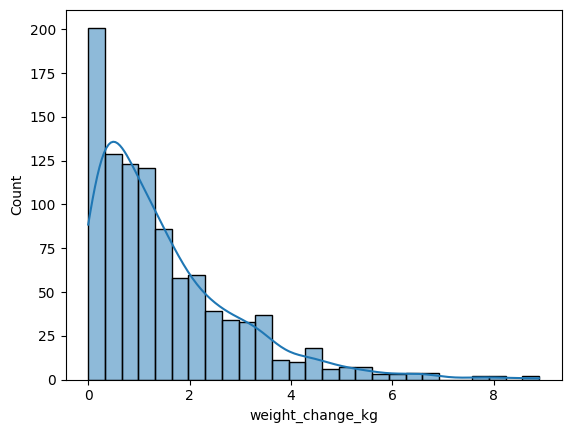

In [48]:
#Is distribution centered around zero?
print(df['weight_change_kg'].describe())
sns.histplot(df['weight_change_kg'], kde=True)
plt.show()

In [49]:
#Does weight gain increase with higher gaming addiction risk levels?
df.groupby('gaming_addiction_risk_level')['weight_change_kg'].mean()

gaming_addiction_risk_level
0    0.965175
1    1.678421
2    2.093506
3    2.647887
Name: weight_change_kg, dtype: float64

In [50]:
#Are extreme values realistic?
Q1 = df['weight_change_kg'].quantile(0.25)
Q3 = df['weight_change_kg'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers=df[(df['weight_change_kg'] < lower) | (df['weight_change_kg'] > upper)]
print(outliers['weight_change_kg'])

0      6.8
17     5.7
91     5.7
105    5.2
120    6.1
149    5.0
183    8.0
231    5.5
267    5.0
342    5.6
421    4.9
436    6.5
442    5.3
474    5.4
500    6.7
505    4.7
528    5.0
529    8.9
540    4.8
606    6.5
631    6.2
635    4.7
636    5.3
657    6.3
677    4.8
689    5.0
705    6.0
719    6.4
767    5.7
783    8.1
792    6.7
813    5.0
826    4.7
842    7.6
895    5.0
924    5.5
932    8.7
939    7.6
943    6.8
946    5.3
Name: weight_change_kg, dtype: float64


Bivariate Analysis

Target vs Daily Gaming Hours

In [51]:
#Does gaming time increase as addiction risk increases?
df.groupby('gaming_addiction_risk_level')['daily_gaming_hours'].mean()

gaming_addiction_risk_level
0    4.020428
1    7.004211
2    8.698701
3    9.961268
Name: daily_gaming_hours, dtype: float64

Target vs Sleep Hours

In [52]:
#Does sleep decrease as addiction risk increases?
df.groupby('gaming_addiction_risk_level')['sleep_hours'].mean()

gaming_addiction_risk_level
0    6.635409
1    5.179474
2    4.506494
3    4.573239
Name: sleep_hours, dtype: float64

In [53]:
#Does average sleep duration differ across gaming addiction risk levels?

low = df[df['gaming_addiction_risk_level']==0]['sleep_hours']
mod = df[df['gaming_addiction_risk_level']==1]['sleep_hours']
high = df[df['gaming_addiction_risk_level']==2]['sleep_hours']
sev = df[df['gaming_addiction_risk_level']==3]['sleep_hours']

stat,Pvalue=f_oneway(low, mod, high, sev)
print("P-Value",Pvalue)
if(Pvalue<0.05):
    print("There is a significant difference")
else:
    print("There is no significant difference")

P-Value 2.1492236299927885e-122
There is a significant difference


Target vs GPA

In [54]:
#Does GPA actually differ by addiction level?
df.groupby('gaming_addiction_risk_level')['grades_gpa'].mean()



gaming_addiction_risk_level
0    2.493288
1    2.541105
2    2.556234
3    2.556056
Name: grades_gpa, dtype: float64

In [55]:
low = df[df['gaming_addiction_risk_level']==0]['grades_gpa']
mod = df[df['gaming_addiction_risk_level']==1]['grades_gpa']
high = df[df['gaming_addiction_risk_level']==2]['grades_gpa']
sev = df[df['gaming_addiction_risk_level']==3]['grades_gpa']

stat,Pvalue=f_oneway(low, mod, high, sev)
print("P-Value: ",Pvalue)
if(Pvalue<0.05):
    print("There is a significant difference")
else:
    print("There is no significant difference")

P-Value:  0.692216863116365
There is no significant difference


Target vs Monthly game spending

In [56]:
#Does spending actually increase with addciation level?
df.groupby('gaming_addiction_risk_level')['monthly_game_spending_usd'].mean()

gaming_addiction_risk_level
0     47.993249
1    102.727263
2    157.626494
3    258.862958
Name: monthly_game_spending_usd, dtype: float64

Target vs Exercise Hours

In [57]:
#Does exercise decreases as addiction level increases?
df.groupby('gaming_addiction_risk_level')['exercise_hours_weekly'].mean()


gaming_addiction_risk_level
0    7.998249
1    6.494737
2    5.750000
3    5.037324
Name: exercise_hours_weekly, dtype: float64

In [58]:

low = df[df['gaming_addiction_risk_level']==0]['exercise_hours_weekly']
mod = df[df['gaming_addiction_risk_level']==1]['exercise_hours_weekly']
high = df[df['gaming_addiction_risk_level']==2]['exercise_hours_weekly']
sev = df[df['gaming_addiction_risk_level']==3]['exercise_hours_weekly']

stat,Pvalue=f_oneway(low, mod, high, sev)

if(Pvalue<0.05):
    print("There is a significant difference")
else:
    print("There is no significant difference")

There is a significant difference


Target vs Social Hours

In [59]:
#Does face-to-face social interaction decrease as gaming addiction risk increases?
df.groupby('gaming_addiction_risk_level')['face_to_face_social_hours_weekly'].mean()


gaming_addiction_risk_level
0    10.168093
1     6.679474
2     4.609091
3     3.163380
Name: face_to_face_social_hours_weekly, dtype: float64

In [60]:
#Is isolation strongly correlated with risk?
df[['face_to_face_social_hours_weekly','gaming_addiction_risk_level']].corr()

,face_to_face_social_hours_weekly,gaming_addiction_risk_level
face_to_face_social_hours_weekly,1.00000,-0.73002
gaming_addiction_risk_level,-0.73002,1.00000


Target vs Years Gaming

In [61]:
#Does long-term exposure increase severity?
df.groupby('gaming_addiction_risk_level')['years_gaming'].mean()

gaming_addiction_risk_level
0    5.945525
1    5.510526
2    5.331169
3    6.140845
Name: years_gaming, dtype: float64

In [62]:
#Are new gamers also severe?
df[df['gaming_addiction_risk_level']==2]['years_gaming'].describe()

count    154.000000
mean       5.331169
std        3.276087
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       16.000000
Name: years_gaming, dtype: float64


Gaming Hours Vs Exercise Hours

In [63]:
#Is there a significant relationship between daily gaming hours and weekly exercise hours?
df[['exercise_hours_weekly','daily_gaming_hours']].corr()

,exercise_hours_weekly,daily_gaming_hours
exercise_hours_weekly,1.000000,-0.763183
daily_gaming_hours,-0.763183,1.000000


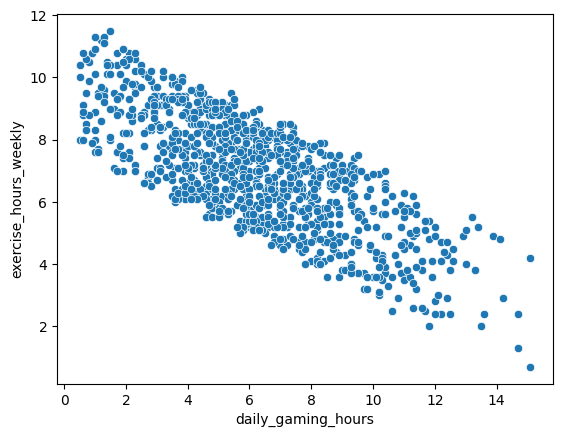

In [64]:
#Does the scatterplot show a clear downward trend as gaming hours increase?
sns.scatterplot(x='daily_gaming_hours', y='exercise_hours_weekly', data=df)
plt.show()

In [65]:
r, p_value = pearsonr(df['daily_gaming_hours'],
                      df['exercise_hours_weekly'])

print("Correlation coefficient:", r)
print("P-value:", p_value)

if(Pvalue<0.05):
    print("There is a significant relationship exists")
else:
    print("There is no significant relationship")

Correlation coefficient: -0.7631833076106045
P-value: 1.79268885325363e-191
There is a significant relationship exists


Gaming Hours vs Sleep


In [66]:
#Is there a strong negative correlation?
df[['sleep_hours','daily_gaming_hours']].corr()

,sleep_hours,daily_gaming_hours
sleep_hours,1.000000,-0.739775
daily_gaming_hours,-0.739775,1.000000


Gaming Hours vs GPA

In [67]:
#Is there a negative relationship?
df[['grades_gpa','daily_gaming_hours']].corr()

,grades_gpa,daily_gaming_hours
grades_gpa,1.000000,0.023083
daily_gaming_hours,0.023083,1.000000


In [68]:
#Is it strong enough to matter?
r, p_value = pearsonr(df['daily_gaming_hours'],
                      df['grades_gpa'])

print("Correlation coefficient:", r)
print("P-value:", p_value)

if(Pvalue<0.05):
    print("There is a significant relationship exists")
else:
    print("There is no significant relationship")

Correlation coefficient: 0.02308287265784473
P-value: 0.46592293038610577
There is a significant relationship exists


Gaming Hours vs Social Hours

In [69]:
#Does more gaming reduce social interaction?
df.groupby('daily_gaming_hours')['face_to_face_social_hours_weekly'].mean()

daily_gaming_hours
0.5     14.333333
0.6     12.620000
0.7     14.000000
0.8     13.833333
0.9     13.600000
          ...    
13.9     0.000000
14.1     0.000000
14.2     0.000000
14.7     0.000000
15.1     0.000000
Name: face_to_face_social_hours_weekly, Length: 132, dtype: float64

In [70]:
r, p_value = pearsonr(df['daily_gaming_hours'],
                      df['grades_gpa'])

print("Correlation coefficient:", r)
print("P-value:", p_value)

if(Pvalue<0.05):
    print("There is a significant relationship exists")
else:
    print("There is no significant relationship")

Correlation coefficient: 0.02308287265784473
P-value: 0.46592293038610577
There is a significant relationship exists


In [71]:
#Is correlation moderate or weak?
df[['face_to_face_social_hours_weekly','daily_gaming_hours']].corr()

,face_to_face_social_hours_weekly,daily_gaming_hours
face_to_face_social_hours_weekly,1.000000,-0.885563
daily_gaming_hours,-0.885563,1.000000
